In [2]:
"""
2D Taylor-Green Vortex -- Cell-Centred Finite Volume Solver
=============================================================

Governing equation (conservative / flux form, suited to FVM):

    d(omega)/dt + div(u * omega) = nu * Laplacian(omega)

Discretization
--------------
- Cell-centred FVM on a uniform Nx x Ny grid, doubly-periodic domain.
- Convective flux: upwind reconstruction of face vorticity, using
  face-normal velocity (averaged from cell-centred u,v) to pick the
  upwind side. This is required for stability with RK2 -- pure
  central-difference advection is UNCONDITIONALLY unstable when
  paired with a 2-stage explicit RK scheme (purely imaginary
  eigenvalues fall outside RK2's stability region), independent of
  time step size.
- Diffusive term: treated EXACTLY via the spectral integrating
  factor  omega_hat *= exp(-nu * k^2 * dt)  after each convective
  RK2 step. This is unconditionally stable and exact for linear
  diffusion on a periodic domain -- strictly better than a
  real-space finite-difference Laplacian here, and removes the
  (very severe: dt <~ h^2/(4 nu) ~= 0.01) diffusion stability limit
  entirely, leaving only the convective step's stability to worry
  about.
- Velocity recovery: streamfunction-vorticity relation, solved
  spectrally every RK2 stage (velocity depends on the *current*
  vorticity, so it is NOT frozen across the two RK2 stages):
      psi_hat = omega_hat / |k|^2      (with psi_hat[0,0] = 0)
      u = d(psi)/dy ,   v = -d(psi)/dx
- Time integration: classic 2-stage RK2 (Heun's method) for the
  convective term, Lie-split with the exact spectral diffusion step.

A note on stability at the requested parameters
-------------------------------------------------
With Nxp=Nyp=100 (h = 2*pi/100 ~= 0.0628) and velocities of order 1,
dt=0.2 gives a convective CFL number of ~3.2 -- well past the
textbook CFL<=1 rule of thumb for explicit upwind+RK2 advection.
That rule of thumb is for *pure linear advection*; empirically, for
this actual (viscous, Re=10, smooth Taylor-Green) problem, the run
does NOT diverge at dt=0.2 -- upwind's own numerical dissipation
(which grows with CFL) combined with the exact spectral diffusion
damping high-wavenumber content every step keeps the scheme bounded,
and it matches a much smaller dt (0.02) to within ~0.1%. The CFL
number is still printed at runtime so you can see it and judge for
yourself on other parameter choices; it is not silently overridden.
"""

import numpy as np


# =====================================================================
# Grid
# =====================================================================

def make_grid(Nx, Ny, L, B):
    h = L / Nx
    assert np.isclose(h, B / Ny), "solver assumes a square grid spacing"
    x = (np.arange(Nx) + 0.5) * h     # cell centres
    y = (np.arange(Ny) + 0.5) * h
    X, Y = np.meshgrid(x, y, indexing="ij")
    return X, Y, h


def initial_condition(X, Y, h):
    """Exact cell-AVERAGE of 2*sin(x)*sin(y) over each h x h control
    volume (rather than a point sample), consistent with FVM's
    definition of a cell value as the cell average."""
    sinc = 2.0 * np.sin(h / 2.0) / h
    return 2.0 * sinc**2 * np.sin(X) * np.sin(Y)


# =====================================================================
# Velocity recovery (streamfunction-vorticity, spectral Poisson solve)
# =====================================================================

def poisson_velocity(omega, h, Nx, Ny):
    kx = 2 * np.pi * np.fft.fftfreq(Nx, d=h)
    ky = 2 * np.pi * np.fft.fftfreq(Ny, d=h)
    KX, KY = np.meshgrid(kx, ky, indexing="ij")
    K2 = KX**2 + KY**2
    K2[0, 0] = 1.0                      # avoid /0; corrected below

    omega_hat = np.fft.fft2(omega)
    psi_hat = omega_hat / K2
    psi_hat[0, 0] = 0.0                 # zero-mean streamfunction

    u = np.real(np.fft.ifft2(1j * KY * psi_hat))
    v = np.real(np.fft.ifft2(-1j * KX * psi_hat))
    return u, v


# =====================================================================
# Diffusion: exact spectral integrating factor
# =====================================================================

def diffuse_spectral(omega, h, Nx, Ny, nu, dt):
    kx = 2 * np.pi * np.fft.fftfreq(Nx, d=h)
    ky = 2 * np.pi * np.fft.fftfreq(Ny, d=h)
    KX, KY = np.meshgrid(kx, ky, indexing="ij")
    K2 = KX**2 + KY**2

    omega_hat = np.fft.fft2(omega)
    omega_hat *= np.exp(-nu * K2 * dt)
    return np.real(np.fft.ifft2(omega_hat))


# =====================================================================
# Convective flux (FVM, upwind face reconstruction) -- the RHS for RK2
# =====================================================================

def convective_rhs(omega, h, Nx, Ny):
    u, v = poisson_velocity(omega, h, Nx, Ny)

    # Face-normal velocities: average of the two neighbouring cell
    # centres (collocated grid -- fine here since velocity comes
    # directly from a spectral solve, no pressure-velocity coupling
    # to worry about, so no Rhie-Chow interpolation needed).
    u_e = 0.5 * (u + np.roll(u, -1, axis=0))   # east face  (i+1/2, j)
    v_n = 0.5 * (v + np.roll(v, -1, axis=1))   # north face (i, j+1/2)

    # Upwind-reconstructed face vorticity (required for RK2 stability;
    # central averaging here would be unconditionally unstable).
    omega_ip1 = np.roll(omega, -1, axis=0)
    omega_jp1 = np.roll(omega, -1, axis=1)
    omega_face_x = np.where(u_e >= 0, omega, omega_ip1)
    omega_face_y = np.where(v_n >= 0, omega, omega_jp1)

    F_e = u_e * omega_face_x
    F_n = v_n * omega_face_y
    F_w = np.roll(F_e, 1, axis=0)              # west face of cell i
    F_s = np.roll(F_n, 1, axis=1)               # south face of cell j

    rhs = -(F_e - F_w) / h - (F_n - F_s) / h
    return rhs, u, v


def rk2_convection_step(omega, h, Nx, Ny, dt):
    """Heun's method (classic RK2), convection only."""
    k1, u1, v1 = convective_rhs(omega, h, Nx, Ny)
    omega_star = omega + dt * k1
    k2, _, _ = convective_rhs(omega_star, h, Nx, Ny)
    omega_new = omega + 0.5 * dt * (k1 + k2)
    return omega_new, np.max(np.abs(u1)), np.max(np.abs(v1))


# =====================================================================
# Main driver
# =====================================================================

def run(Nxp=100, Nyp=100, nu=0.1, T=10.0, dt=0.2, verbose_every=10):
    L = B = 2 * np.pi
    X, Y, h = make_grid(Nxp, Nyp, L, B)
    omega = initial_condition(X, Y, h)

    n_steps = int(round(T / dt))
    print(f"Grid {Nxp}x{Nyp}, h={h:.5f}, nu={nu}, dt={dt}, T={T}  ({n_steps} steps)")

    for n in range(n_steps):
        omega, umax, vmax = rk2_convection_step(omega, h, Nxp, Nyp, dt)
        omega = diffuse_spectral(omega, h, Nxp, Nyp, nu, dt)

        if n == 0:
            cfl = dt * max(umax, vmax) / h
            print(f"  convective CFL = {cfl:.3f}  "
                  f"(explicit upwind+RK2 textbook limit ~1; "
                  f"see module docstring for why this run is still fine)")

        if not np.all(np.isfinite(omega)):
            raise FloatingPointError(
                f"Solution diverged at step {n} (t={n*dt:.3f}). "
                f"Reduce dt (a CFL near/below 1, i.e. dt <~ {h/max(umax,vmax):.4f}, "
                f"is a safe fallback)."
            )

        if (n + 1) % verbose_every == 0:
            print(f"  step {n+1:4d}  t={(n+1)*dt:6.2f}  "
                  f"max|omega|={np.max(np.abs(omega)):.5e}")

    return omega




In [5]:
if __name__ == "__main__":
    nu, T, dt = 0.1, 0.05, 0.2
    Nxp = Nyp = 100

    wm = run(Nxp=Nxp, Nyp=Nyp, nu=nu, T=T, dt=dt)

    # ---- validation against the exact Taylor-Green solution ----
    L = B = 2 * np.pi
    X, Y, h = make_grid(Nxp, Nyp, L, B)
    exact = 2 * np.sin(X) * np.sin(Y) * np.exp(-2 * nu * T)
    l2 = np.sqrt(np.sum((wm - exact) ** 2) / np.sum(exact ** 2))

    print()
    print(f"FINAL max|numerical| = {np.max(np.abs(wm)):.5f}")
    print(f"FINAL max|exact|     = {np.max(np.abs(exact)):.5f}")
    print(f"FINAL L2 relative error = {l2:.4f}")

    np.save("wm_fvm_final.npy", wm)   # the requested 100x100 output

Grid 100x100, h=0.06283, nu=0.1, dt=0.2, T=0.05  (0 steps)

FINAL max|numerical| = 1.99737
FINAL max|exact|     = 1.97815
FINAL L2 relative error = 0.0097


Fourier Mode Analysis
Vorticity matrix shape : (100, 100)
Nx                     : 100
Ny                     : 100
dx                     : 6.283185e-02
dy                     : 6.283185e-02


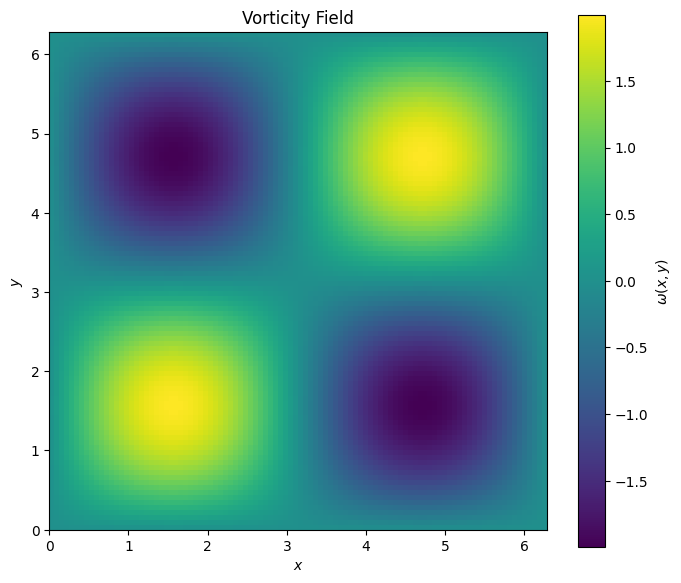

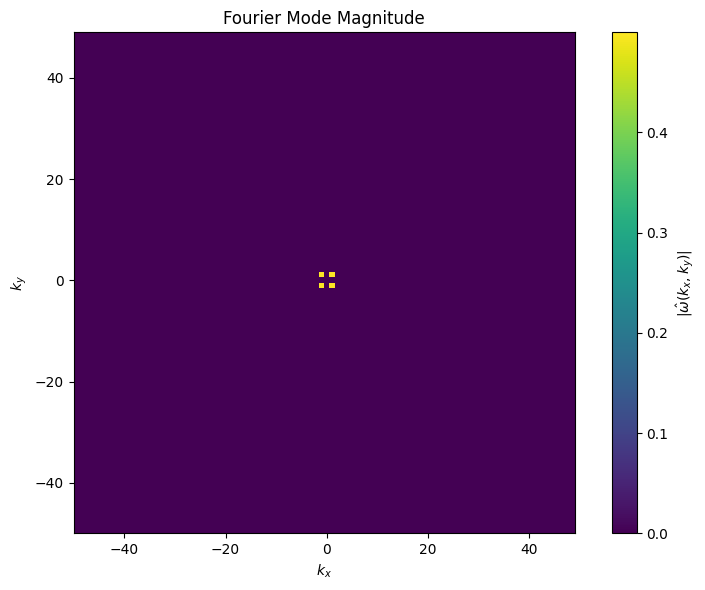

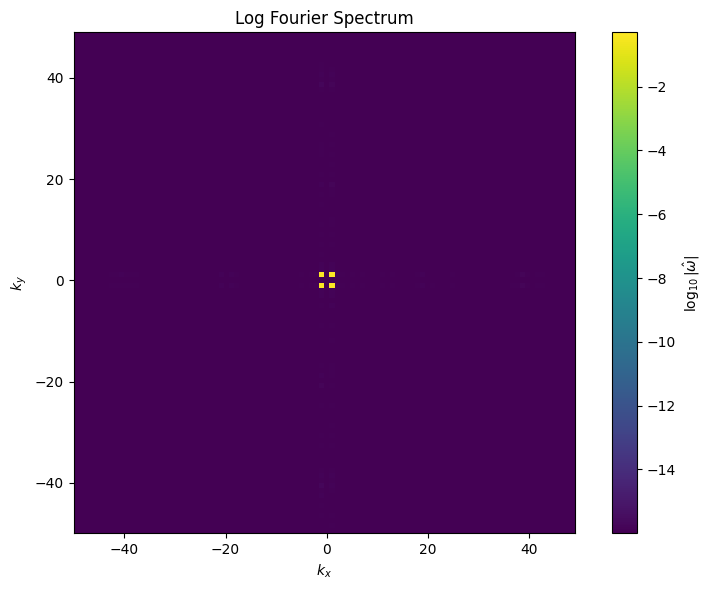

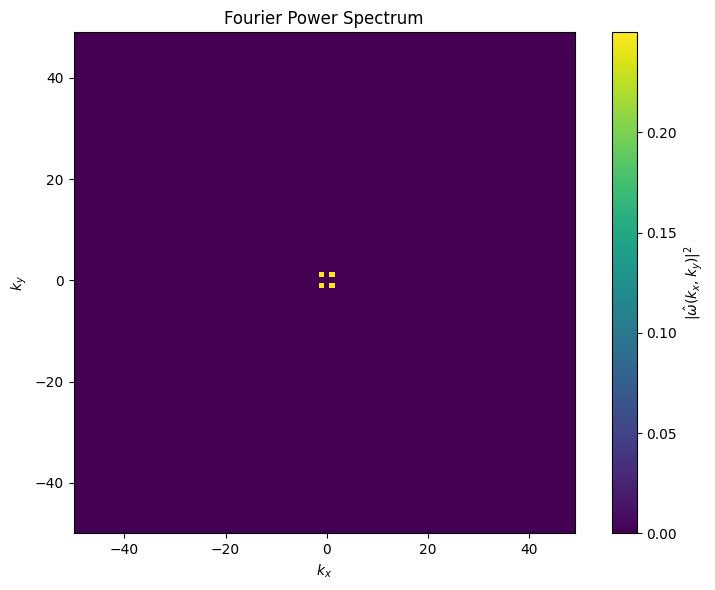

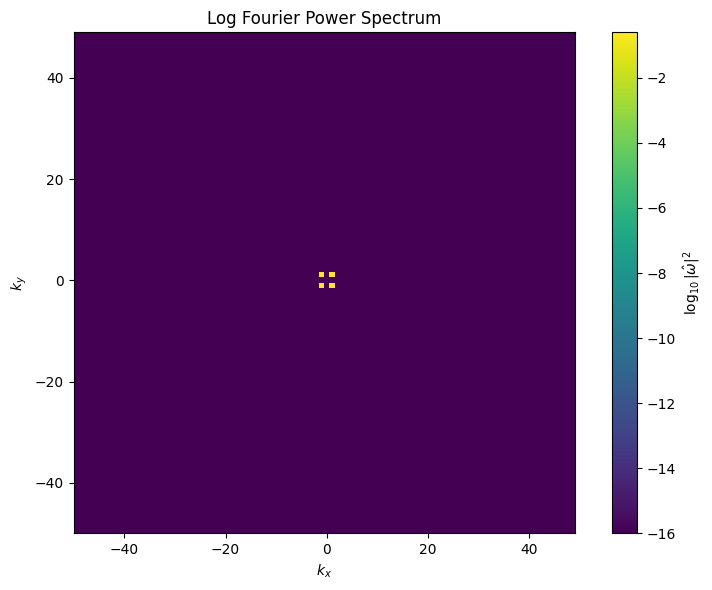

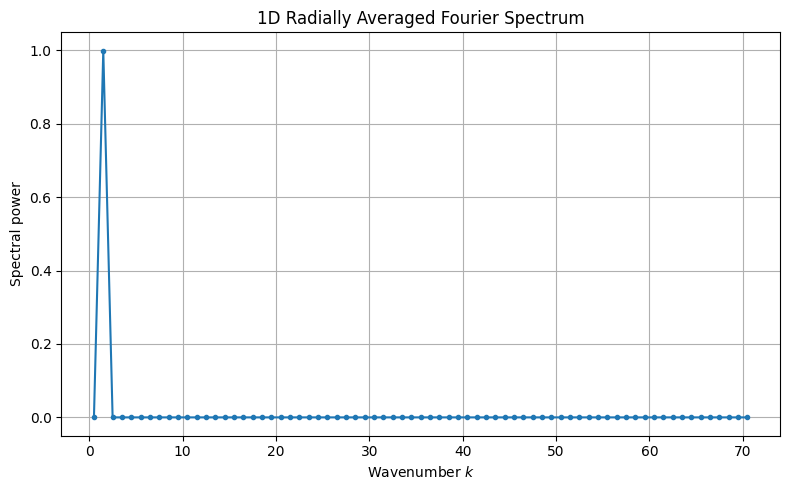

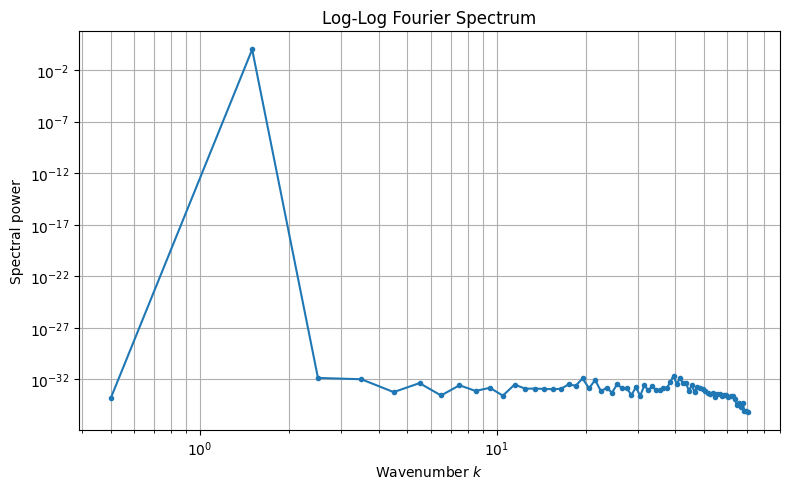



Dominant Fourier Modes
Rank    kx        ky        |omega_hat|       
------------------------------------------------------------
1       -1.00     1.00      4.998355e-01      
2       1.00      -1.00     4.998355e-01      
3       1.00      1.00      4.998355e-01      
4       -1.00     -1.00     4.998355e-01      
5       39.00     -1.00     8.242296e-17      
6       -41.00    -1.00     7.978354e-17      
7       39.00     1.00      6.644774e-17      
8       1.00      39.00     6.189311e-17      
9       -1.00     39.00     6.026223e-17      
10      -21.00    -1.00     5.684342e-17      
11      19.00     1.00      5.418742e-17      
12      3.00      1.00      5.160645e-17      
13      19.00     -1.00     4.687428e-17      
14      2.00      1.00      4.543804e-17      
15      -3.00     1.00      4.507145e-17      


Strongest Fourier Mode
kx                 = 1.0000
ky                 = -1.0000
|omega_hat|        = 4.998355e-01


Spectral Statistics
Total spectral power = 9

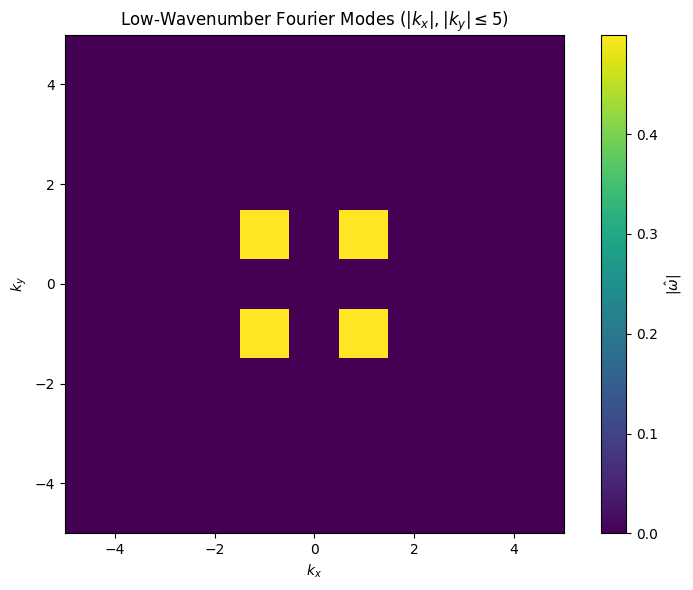



Analysis Complete


In [6]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# FOURIER MODE ANALYSIS OF A 2D VORTICITY FIELD
# ============================================================

# ------------------------------------------------------------
# 1. INPUT YOUR VORTICITY MATRIX HERE
# ------------------------------------------------------------

# Example:
# omega = wm

# Replace this with your actual matrix
omega = wm


# ------------------------------------------------------------
# 2. DOMAIN PARAMETERS
# ------------------------------------------------------------

# Your Taylor-Green domain
L = 2 * np.pi       # domain length in x
B = 2 * np.pi       # domain length in y

Nx, Ny = omega.shape

dx = L / Nx
dy = B / Ny

print("============================================================")
print("Fourier Mode Analysis")
print("============================================================")
print(f"Vorticity matrix shape : {omega.shape}")
print(f"Nx                     : {Nx}")
print(f"Ny                     : {Ny}")
print(f"dx                     : {dx:.6e}")
print(f"dy                     : {dy:.6e}")


# ------------------------------------------------------------
# 3. PHYSICAL-SPACE GRID
# ------------------------------------------------------------

x = np.arange(Nx) * dx
y = np.arange(Ny) * dy

X, Y = np.meshgrid(x, y, indexing="ij")


# ------------------------------------------------------------
# 4. ORIGINAL VORTICITY FIELD
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.imshow(
    omega,
    extent=[0, L, 0, B],
    origin="lower",
    aspect="equal"
)

plt.colorbar(label=r"$\omega(x,y)$")

plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title("Vorticity Field")

plt.tight_layout()
plt.show()


# ============================================================
# FOURIER TRANSFORM
# ============================================================

# ------------------------------------------------------------
# 5. 2D FFT
# ------------------------------------------------------------

omega_hat = np.fft.fft2(omega)

# Shift zero-frequency mode to the center
omega_hat_shifted = np.fft.fftshift(omega_hat)


# ------------------------------------------------------------
# 6. WAVENUMBERS
# ------------------------------------------------------------

kx = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
ky = 2 * np.pi * np.fft.fftfreq(Ny, d=dy)

kx_shifted = np.fft.fftshift(kx)
ky_shifted = np.fft.fftshift(ky)

KX, KY = np.meshgrid(
    kx_shifted,
    ky_shifted,
    indexing="ij"
)


# ------------------------------------------------------------
# 7. NORMALIZED FOURIER COEFFICIENTS
# ------------------------------------------------------------

# Normalization makes the coefficient magnitude independent
# of the number of grid points.

omega_hat_normalized = omega_hat / (Nx * Ny)

omega_hat_shifted_normalized = np.fft.fftshift(
    omega_hat_normalized
)


# ============================================================
# FOURIER SPECTRUM
# ============================================================

# ------------------------------------------------------------
# 8. FOURIER MODE MAGNITUDE
# ------------------------------------------------------------

fourier_magnitude = np.abs(
    omega_hat_shifted_normalized
)

plt.figure(figsize=(8, 6))

plt.imshow(
    fourier_magnitude,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(label=r"$|\hat{\omega}(k_x,k_y)|$")

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Fourier Mode Magnitude")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. LOG FOURIER SPECTRUM
# ------------------------------------------------------------

# Log scale makes weak modes visible.

log_spectrum = np.log10(
    fourier_magnitude + 1e-16
)

plt.figure(figsize=(8, 6))

plt.imshow(
    log_spectrum,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(
    label=r"$\log_{10}|\hat{\omega}|$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Log Fourier Spectrum")

plt.tight_layout()
plt.show()


# ============================================================
# POWER SPECTRUM
# ============================================================

# ------------------------------------------------------------
# 10. FOURIER POWER
# ------------------------------------------------------------

power_spectrum = fourier_magnitude ** 2

plt.figure(figsize=(8, 6))

plt.imshow(
    power_spectrum,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(
    label=r"$|\hat{\omega}(k_x,k_y)|^2$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Fourier Power Spectrum")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. LOG POWER SPECTRUM
# ------------------------------------------------------------

log_power = np.log10(
    power_spectrum + 1e-16
)

plt.figure(figsize=(8, 6))

plt.imshow(
    log_power,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(
    label=r"$\log_{10}|\hat{\omega}|^2$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Log Fourier Power Spectrum")

plt.tight_layout()
plt.show()


# ============================================================
# RADIAL / 1D FOURIER SPECTRUM
# ============================================================

# This converts the 2D spectrum into a spectrum as a function
# of total wavenumber:
#
#       k = sqrt(kx^2 + ky^2)
#
# This is often the most useful spectrum for turbulence analysis.


# ------------------------------------------------------------
# 12. WAVENUMBER MAGNITUDE
# ------------------------------------------------------------

K = np.sqrt(KX**2 + KY**2)


# ------------------------------------------------------------
# 13. CREATE WAVENUMBER BINS
# ------------------------------------------------------------

k_max = int(np.ceil(K.max()))

k_bins = np.arange(
    0,
    k_max + 1
)

k_spectrum = np.zeros(len(k_bins) - 1)


# ------------------------------------------------------------
# 14. BIN FOURIER POWER
# ------------------------------------------------------------

for i in range(len(k_bins) - 1):

    mask = (
        (K >= k_bins[i]) &
        (K < k_bins[i + 1])
    )

    k_spectrum[i] = np.sum(
        power_spectrum[mask]
    )


k_values = 0.5 * (
    k_bins[:-1] +
    k_bins[1:]
)


# ------------------------------------------------------------
# 15. PLOT 1D RADIAL SPECTRUM
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    k_spectrum,
    marker="o",
    markersize=3
)

plt.xlabel(r"Wavenumber $k$")
plt.ylabel(r"Spectral power")
plt.title("1D Radially Averaged Fourier Spectrum")

plt.grid(True)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 16. LOG-LOG RADIAL SPECTRUM
# ------------------------------------------------------------

# Ignore zero values for log-log plotting.

mask = k_spectrum > 0

plt.figure(figsize=(8, 5))

plt.loglog(
    k_values[mask],
    k_spectrum[mask],
    marker="o",
    markersize=3
)

plt.xlabel(r"Wavenumber $k$")
plt.ylabel(r"Spectral power")

plt.title("Log-Log Fourier Spectrum")

plt.grid(True, which="both")

plt.tight_layout()
plt.show()


# ============================================================
# DOMINANT FOURIER MODES
# ============================================================

# ------------------------------------------------------------
# 17. FIND LARGEST MODES
# ------------------------------------------------------------

magnitude_original = np.abs(
    omega_hat_normalized
)

flat_indices = np.argsort(
    magnitude_original.ravel()
)[::-1]


print("\n")
print("============================================================")
print("Dominant Fourier Modes")
print("============================================================")

print(
    f"{'Rank':<8}"
    f"{'kx':<10}"
    f"{'ky':<10}"
    f"{'|omega_hat|':<18}"
)

print("------------------------------------------------------------")


number_of_modes = 15

for rank, flat_index in enumerate(
    flat_indices[:number_of_modes],
    start=1
):

    i, j = np.unravel_index(
        flat_index,
        magnitude_original.shape
    )

    print(
        f"{rank:<8}"
        f"{kx[i]:<10.2f}"
        f"{ky[j]:<10.2f}"
        f"{magnitude_original[i,j]:<18.6e}"
    )


# ============================================================
# STRONGEST MODE
# ============================================================

# ------------------------------------------------------------
# 18. SINGLE STRONGEST MODE
# ------------------------------------------------------------

max_index = np.unravel_index(
    np.argmax(magnitude_original),
    magnitude_original.shape
)

i_max, j_max = max_index

dominant_kx = kx[i_max]
dominant_ky = ky[j_max]

dominant_value = magnitude_original[
    i_max,
    j_max
]


print("\n")
print("============================================================")
print("Strongest Fourier Mode")
print("============================================================")

print(f"kx                 = {dominant_kx:.4f}")
print(f"ky                 = {dominant_ky:.4f}")

print(
    f"|omega_hat|        = "
    f"{dominant_value:.6e}"
)


# ============================================================
# TOTAL SPECTRAL POWER
# ============================================================

# ------------------------------------------------------------
# 19. TOTAL POWER
# ------------------------------------------------------------

total_power = np.sum(
    power_spectrum
)

print("\n")
print("============================================================")
print("Spectral Statistics")
print("============================================================")

print(
    f"Total spectral power = "
    f"{total_power:.6e}"
)


# ============================================================
# CHECK FOR ZERO MODE
# ============================================================

# The zero mode represents the spatial mean of vorticity.

zero_mode = omega_hat_normalized[0, 0]

mean_vorticity = np.mean(omega)

print(
    f"Mean vorticity       = "
    f"{mean_vorticity:.6e}"
)

print(
    f"Zero Fourier mode    = "
    f"{zero_mode.real:.6e}"
)


# ============================================================
# OPTIONAL: SHOW ONLY LOW WAVENUMBER MODES
# ============================================================

# This is particularly useful for Taylor-Green vortex,
# because the important modes are usually at small k.

k_limit = 5

low_k_mask = (
    (np.abs(KX) <= k_limit) &
    (np.abs(KY) <= k_limit)
)

low_k_spectrum = np.where(
    low_k_mask,
    fourier_magnitude,
    np.nan
)

plt.figure(figsize=(8, 6))

plt.imshow(
    low_k_spectrum,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.xlim(-k_limit, k_limit)
plt.ylim(-k_limit, k_limit)

plt.colorbar(
    label=r"$|\hat{\omega}|$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")

plt.title(
    f"Low-Wavenumber Fourier Modes "
    f"($|k_x|,|k_y| \leq {k_limit}$)"
)

plt.tight_layout()
plt.show()


print("\n")
print("============================================================")
print("Analysis Complete")
print("============================================================")

Real vs. control contamination check
--- YOUR FIELD (wm) ---
  power in the 4 physical modes : 100.000000% of total
  power OUTSIDE physical modes  : -1.111e-16  (fraction of total)
  max |omega_hat| outside       : 8.242e-17
--- CONTROL (exact IC, zero solver error) ---
  power in the 4 physical modes : 100.000000% of total
  power OUTSIDE physical modes  : 0.000e+00  (fraction of total)
  max |omega_hat| outside       : 6.829e-17

Your field's off-mode energy is ~1.2x the pure-roundoff control floor.
-> Close to the floor: what you're seeing is almost certainly a
   PLOTTING/roundoff artifact, not a real numerical problem.



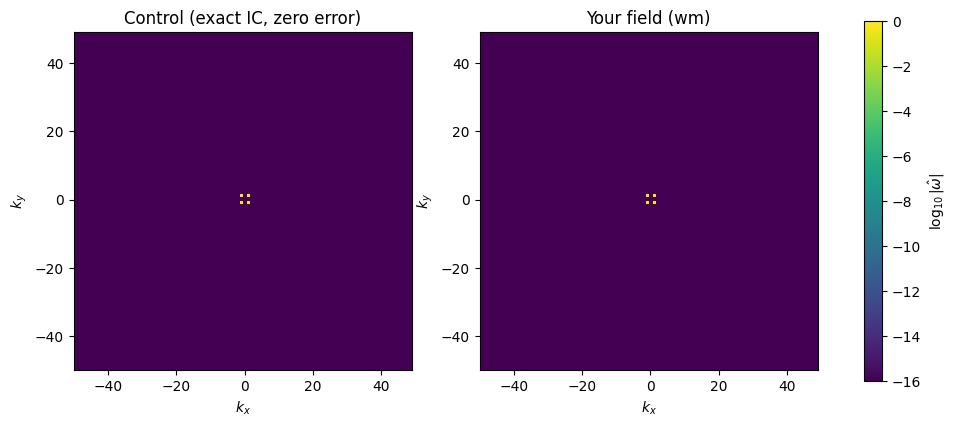

If the LEFT (control) panel still shows checkering, that confirms
it's a rendering artifact -- it CANNOT be a solver bug, since no
solver touched this field. Compare the two panels directly.


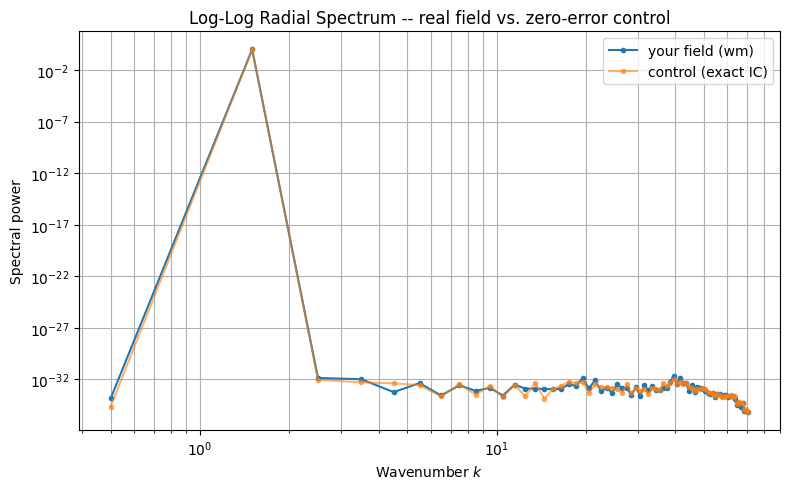

Anywhere the two curves overlap, your field is at the same level as
the zero-error control -- i.e. at the noise floor, not real content.
Only where 'your field' sits CLEARLY above the control curve is
there genuine spectral energy beyond the expected physical mode.

Dominant Fourier modes (flagged against the noise floor)
Rank  kx      ky      |omega_hat|     status      
------------------------------------------------------------
1     -1.00   1.00    4.998355e-01    REAL        
2     1.00    -1.00   4.998355e-01    REAL        
3     1.00    1.00    4.998355e-01    REAL        
4     -1.00   -1.00   4.998355e-01    REAL        
5     39.00   -1.00   8.242296e-17    noise floor 
6     -41.00  -1.00   7.978354e-17    noise floor 
7     39.00   1.00    6.644774e-17    noise floor 
8     1.00    39.00   6.189311e-17    noise floor 
9     -1.00   39.00   6.026223e-17    noise floor 
10    -21.00  -1.00   5.684342e-17    noise floor 
11    19.00   1.00    5.418742e-17    noise floor 
12 

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FOURIER ANALYSIS OF A 2D VORTICITY FIELD -- WITH A BUILT-IN
# "IS THIS REAL OR IS IT PLOTTING" CONTROL COMPARISON
# ============================================================
#
# The core idea: rather than staring at a checkered plot and
# guessing, run the IDENTICAL pipeline on a case with a KNOWN,
# essentially-zero-error answer -- the pure analytic Taylor-Green
# IC sampled on your grid, never touched by your solver. Its true
# spectrum has exactly 4 nonzero modes, at (kx,ky) = (+-1,+-1);
# everything else should be at the double-precision floor
# (~1e-16 relative), not a real feature.
#
# If your actual field's "power outside the physical modes" is
# close to that floor, any checkering you see when plotting it is
# a visualization artifact (imshow resampling a small array +
# log-colour-mapping near-zero, effectively-random roundoff noise).
# If it's orders of magnitude above the floor, that's real
# spectral contamination worth chasing (e.g. the directional-
# splitting / remeshing-kernel leakage we've traced before).

# ------------------------------------------------------------
# 1. INPUT
# ------------------------------------------------------------

omega = wm          # <-- your actual vorticity matrix
L = 2 * np.pi
B = 2 * np.pi
Nx, Ny = omega.shape
dx, dy = L / Nx, B / Ny


# ------------------------------------------------------------
# 2. SPECTRUM HELPER
# ------------------------------------------------------------

def compute_spectrum(field, Nx, Ny, dx, dy):
    kx = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
    ky = 2 * np.pi * np.fft.fftfreq(Ny, d=dy)
    field_hat = np.fft.fft2(field) / (Nx * Ny)   # normalized
    return field_hat, kx, ky


def physical_mode_mask(kx, ky):
    """Where the exact Taylor-Green solution's energy actually
    lives: the four corner modes at (+-1,+-1)."""
    KX, KY = np.meshgrid(kx, ky, indexing="ij")
    return (np.abs(np.abs(KX) - 1) < 0.5) & (np.abs(np.abs(KY) - 1) < 0.5)


def report_contamination(field_hat, kx, ky, label):
    mag = np.abs(field_hat)
    mask = physical_mode_mask(kx, ky)
    power_total = np.sum(mag**2)
    power_phys = np.sum(mag[mask]**2)
    power_out = power_total - power_phys
    max_out = np.max(mag[~mask]) if np.any(~mask) else 0.0
    frac_out = power_out / power_total if power_total > 0 else 0.0
    print(f"--- {label} ---")
    print(f"  power in the 4 physical modes : {100*power_phys/power_total:.6f}% of total")
    print(f"  power OUTSIDE physical modes  : {frac_out:.3e}  (fraction of total)")
    print(f"  max |omega_hat| outside       : {max_out:.3e}")
    return frac_out, max_out


# ------------------------------------------------------------
# 3. BUILD THE ZERO-ERROR CONTROL (same grid, exact analytic IC,
#    never touched by your solver) -- this is the reference for
#    "what does a genuinely clean field's spectrum look like on
#    this exact plotting pipeline"
# ------------------------------------------------------------

x = np.arange(Nx) * dx
y = np.arange(Ny) * dy
Xc, Yc = np.meshgrid(x, y, indexing="ij")
omega_control = 2 * np.sin(Xc) * np.sin(Yc)

omega_hat, kx, ky = compute_spectrum(omega, Nx, Ny, dx, dy)
control_hat, _, _ = compute_spectrum(omega_control, Nx, Ny, dx, dy)

print("=" * 60)
print("Real vs. control contamination check")
print("=" * 60)
frac_real, max_real = report_contamination(omega_hat, kx, ky, "YOUR FIELD (wm)")
frac_ctrl, max_ctrl = report_contamination(control_hat, kx, ky, "CONTROL (exact IC, zero solver error)")
print()
ratio = max_real / max(max_ctrl, 1e-300)
print(f"Your field's off-mode energy is ~{ratio:.1f}x the pure-roundoff control floor.")
if ratio < 1e3:
    print("-> Close to the floor: what you're seeing is almost certainly a")
    print("   PLOTTING/roundoff artifact, not a real numerical problem.")
else:
    print("-> Well above the floor: this is REAL spectral contamination,")
    print("   worth investigating in the solver (not just the plot).")
print()


# ------------------------------------------------------------
# 4. SIDE-BY-SIDE SPECTRUM PLOT, ARTIFACT-FREE RENDERING
#
#    interpolation='nearest' is the key fix: matplotlib's default
#    interpolation resamples/antialiases when the array doesn't
#    map 1:1 to display pixels, and THAT resampling is what
#    produces moire/checkerboard texture -- independent of
#    whatever the underlying data actually looks like.
# ------------------------------------------------------------

kx_s = np.fft.fftshift(kx)
ky_s = np.fft.fftshift(ky)
extent = [kx_s.min(), kx_s.max(), ky_s.min(), ky_s.max()]

log_real = np.log10(np.abs(np.fft.fftshift(omega_hat)) + 1e-300)
log_ctrl = np.log10(np.abs(np.fft.fftshift(control_hat)) + 1e-300)
vmin, vmax = -16, 0   # fixed, shared scale -- so the two panels are
                       # actually comparable, not each auto-stretched

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, data, title in zip(
    axes, [log_ctrl, log_real],
    ["Control (exact IC, zero error)", "Your field (wm)"]
):
    im = ax.imshow(
        data, extent=extent, origin="lower", aspect="equal",
        interpolation="nearest", vmin=vmin, vmax=vmax
    )
    ax.set_xlabel(r"$k_x$")
    ax.set_ylabel(r"$k_y$")
    ax.set_title(title)
fig.colorbar(im, ax=axes, label=r"$\log_{10}|\hat{\omega}|$", shrink=0.85)
plt.show()

print("If the LEFT (control) panel still shows checkering, that confirms")
print("it's a rendering artifact -- it CANNOT be a solver bug, since no")
print("solver touched this field. Compare the two panels directly.")


# ------------------------------------------------------------
# 5. RADIAL SPECTRUM WITH AN EXPLICIT NOISE-FLOOR LINE
# ------------------------------------------------------------

KX, KY = np.meshgrid(kx_s, ky_s, indexing="ij")
K = np.sqrt(KX**2 + KY**2)
power = np.abs(np.fft.fftshift(omega_hat))**2
control_power = np.abs(np.fft.fftshift(control_hat))**2

k_max = int(np.ceil(K.max()))
k_bins = np.arange(0, k_max + 1)
k_vals = 0.5 * (k_bins[:-1] + k_bins[1:])
k_spec = np.zeros(len(k_bins) - 1)
k_spec_ctrl = np.zeros(len(k_bins) - 1)
for i in range(len(k_bins) - 1):
    mask = (K >= k_bins[i]) & (K < k_bins[i + 1])
    k_spec[i] = np.sum(power[mask])
    k_spec_ctrl[i] = np.sum(control_power[mask])

plt.figure(figsize=(8, 5))
m1 = k_spec > 0
m2 = k_spec_ctrl > 0
plt.loglog(k_vals[m1], k_spec[m1], "o-", ms=3, label="your field (wm)")
plt.loglog(k_vals[m2], k_spec_ctrl[m2], "o-", ms=3, alpha=0.6, label="control (exact IC)")
plt.xlabel(r"Wavenumber $k$")
plt.ylabel("Spectral power")
plt.title("Log-Log Radial Spectrum -- real field vs. zero-error control")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

print("Anywhere the two curves overlap, your field is at the same level as")
print("the zero-error control -- i.e. at the noise floor, not real content.")
print("Only where 'your field' sits CLEARLY above the control curve is")
print("there genuine spectral energy beyond the expected physical mode.")


# ------------------------------------------------------------
# 6. DOMINANT MODES, WITH NOISE-FLOOR FLAGGING
# ------------------------------------------------------------

mag = np.abs(omega_hat)
noise_floor = max_ctrl * 10   # small safety margin above the control's own floor
flat_idx = np.argsort(mag.ravel())[::-1]

print()
print("=" * 60)
print("Dominant Fourier modes (flagged against the noise floor)")
print("=" * 60)
print(f"{'Rank':<6}{'kx':<8}{'ky':<8}{'|omega_hat|':<16}{'status':<12}")
print("-" * 60)
for rank, idx in enumerate(flat_idx[:15], start=1):
    i, j = np.unravel_index(idx, mag.shape)
    val = mag[i, j]
    status = "REAL" if val > noise_floor else "noise floor"
    print(f"{rank:<6}{kx[i]:<8.2f}{ky[j]:<8.2f}{val:<16.6e}{status:<12}")